# 3C-FBI — Comparison of 5 Implementations

Runs the same Experiments A, B1, B2 used in the paper on these five implementations:

| Label | File | Role |
|---|---|---|
| **v1** | `CCC_FBI.py` | Original (kept for ablation) |
| **v2** | `CCC_FBI_v2.py` | Dense vote map + multi-k |
| **v3 ★** | `CCC_FBI_v3.py` | **Published** (cube_size=3) |
| **ChatGPT** | `CCC_FBI_ChatGPT.py` | LLM-generated reference |
| **Gemini** | `CCC_FBI_Gemini.py` | LLM-generated reference |

**Estimated runtimes** (N_MC_B2 = 20):
- Exp A (best 3 GL configs): ~2 min
- Exp B1: ~30 s
- Exp B2: ~5–8 min

> Set `EXP_A_CONFIGS`, `N_MC_B1`, `N_MC_B2` in the **Configuration** cell to trade speed vs. precision.

In [ ]:
# ── mock numba BEFORE importing any CCC_FBI module ────────────────────────
import sys, os
from unittest.mock import MagicMock
_numba = MagicMock()
_numba.jit = lambda *a, **kw: (lambda f: f)
sys.modules['numba'] = _numba

# Find project root — notebook lives in PROJECT/notebooks/
_here = os.getcwd()
PROJECT = os.path.dirname(_here) if os.path.basename(_here) == 'notebooks' else _here
if PROJECT not in sys.path:
    sys.path.insert(0, PROJECT)

import io, time, contextlib, math as m
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from scipy.stats import wilcoxon

from algorithms.CCC_FBI         import ccc_fbi           as _v1
from algorithms.CCC_FBI_v2      import ccc_fbi_v2        as _v2
from algorithms.CCC_FBI_v3      import ccc_fbi_v3        as _v3
from algorithms.CCC_FBI_ChatGPT import fit_circle_3cfbi  as _chatgpt
from algorithms.CCC_FBI_Gemini  import CCCFBI            as _GeminiClass
from algorithms.preprocessing   import (preprocess_green_level,
                                        preprocess_median_filter,
                                        get_preprocessing_configs)
print('Imports OK — PROJECT:', PROJECT)

In [2]:
# ── Configuration — edit here ──────────────────────────────────────────────

# Exp A: which preprocessing configs to run (subset for speed)
# Full list: GL70..GL86, Med3..Med19
EXP_A_CONFIGS = ['GL80', 'GL82', 'GL84']   # best-3-GL (paper default)
# EXP_A_CONFIGS = None                      # all 18 configs (~6× slower)

# Monte Carlo iterations (100 = paper quality, 20 = quick preview)
N_MC_B1 = 100
N_MC_B2 = 20

# ── Fixed experiment constants (match paper) ───────────────────────────────
B1_X0, B1_Y0, B1_R0 = 50,  60,  100
B2_X0, B2_Y0, B2_R0 = 120, 120, 120
B2_N               = 100

NOISE_PCT   = [0, 1, 2, 5, 10]
OUTLIER_PCT = [0, 10, 20, 30, 40, 50, 60, 70]
Q_VALUES    = [0, 1, 2, 3, 4, 6, 12, 24, 40]

METHODS = ['v1', 'v2', 'v3 ★', 'ChatGPT', 'Gemini']
COLORS  = {'v1':'#8da0cb', 'v2':'#fc8d62', 'v3 ★':'#e41a1c',
           'ChatGPT':'#4daf4a', 'Gemini':'#984ea3'}

In [3]:
# ── Shared helpers ─────────────────────────────────────────────────────────

def jaccard_circles(x1, y1, r1, x2, y2, r2):
    d = np.sqrt((x1-x2)**2 + (y1-y2)**2)
    if d == 0: return min((r1/r2)**2, (r2/r1)**2)
    d1 = (d**2 + r1**2 - r2**2) / (2*d)
    d2 = d - d1
    R, r = max(r1, r2), min(r1, r2)
    if d >= r1 + r2:   return 0.0
    elif d <= R - r:   return (r/R)**2
    a1 = 2*m.acos(max(-1., min(1., d1/r1)))
    a2 = 2*m.acos(max(-1., min(1., d2/r2)))
    inter = .5*r1**2*(a1-m.sin(a1)) + .5*r2**2*(a2-m.sin(a2))
    return inter / (m.pi*(R**2+r**2) - inter)


def generate_semicircle(x0, y0, r0, n=50, noise=1.0, n_out=0, rng=None):
    if rng is None: rng = np.random.default_rng()
    theta = rng.uniform(0, np.pi, n)
    noise1 = rng.normal(0, noise, n)
    x = x0 + (r0 + noise1)*np.cos(theta)
    y = y0 + (r0 + noise1)*np.sin(theta)
    if n_out > 0:
        for idx in rng.choice(n, min(n_out, n), replace=False):
            s = 2*round(rng.uniform(0,1))-1
            f = rng.uniform(9,10)*noise*s
            x[idx] = x0+(r0+f)*np.cos(theta[idx])
            y[idx] = y0+(r0+f)*np.sin(theta[idx])
    return np.column_stack([x, y])


def generate_circle(x0, y0, r0, n=100, noise=0., n_out=0, rng=None):
    if rng is None: rng = np.random.default_rng()
    theta = rng.uniform(0, 2*np.pi, n)
    r_n   = rng.normal(0, noise, n)
    x = x0 + (r0+r_n)*np.cos(theta)
    y = y0 + (r0+r_n)*np.sin(theta)
    if n_out > 0:
        for idx in rng.choice(n, min(n_out, n), replace=False):
            s = 2*round(rng.uniform(0,1))-1
            f = rng.uniform(5,20)*noise*s
            x[idx] = x0+(r0+f)*np.cos(theta[idx])
            y[idx] = y0+(r0+f)*np.sin(theta[idx])
    return np.column_stack([x, y])


def apply_quantization(pts, q):
    if q == 0: return pts
    return np.unique(np.round(pts / q), axis=0)


def pts_to_img(pts, x_shift=0, y_shift=0, H=300, W=300):
    """Point cloud (x,y) → binary image. Optional shift for negative coords."""
    img = np.zeros((H, W), dtype=np.uint8)
    for x, y in pts:
        xi = int(round(x + x_shift))
        yi = int(round(y + y_shift))
        if 0 <= yi < H and 0 <= xi < W:
            img[yi, xi] = 255
    return img

print('Helpers OK')

Helpers OK


In [ ]:
# ── Per-implementation wrappers ────────────────────────────────────────────
#
# Experiment A:  edgels are [row, col] from preprocessing.
#   v1/v2/v3 treat col=0 as x and row=1 as y internally.
#   ChatGPT/Gemini receive the binary edge image (GreenCanny);
#   their returned (x=col, y=row) is swapped back to (row, col).
#   Jaccard: jaccard_circles(YGT, XGT, RGT, center[0], center[1], r)
#             where center[0]=row, center[1]=col.
#
# Experiments B1/B2:  points are (x, y). All wrappers return (cx, cy, r)
#   in the same (x, y) space.

NMAX  = 5000
TOP_N = 5
TAU   = 1   # cube_size = 2*TAU+1 = 3

# ── Exp A wrappers: receive edgels [row,col] + binary image, return (row,col,r)

def _wrap_v1_A(edgels, edge_img, xmax, ymax):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        c, r = _v1(edgels, Nmax=NMAX, xmax=xmax, ymax=ymax,
                   rmin=4, rmax=40, top_n=TOP_N)
    return (c[0], c[1], float(r)) if r > 0 else None

def _wrap_v2_A(edgels, edge_img, xmax, ymax):
    c, r = _v2(edgels, Nmax=NMAX, xmax=xmax, ymax=ymax, rmin=4, rmax=40)
    return (c[0], c[1], float(r)) if r > 0 else None

def _wrap_v3_A(edgels, edge_img, xmax, ymax):
    c, r = _v3(edgels, Nmax=NMAX, xmax=xmax, ymax=ymax,
               rmin=4, rmax=40, top_n=TOP_N, cube_size=2*TAU+1)
    return (c[0], c[1], float(r)) if r > 0 else None

def _wrap_chatgpt_A(edgels, edge_img, xmax, ymax):
    try:
        est = _chatgpt(edge_img, x_max=xmax, y_max=ymax,
                       r_min=4, r_max=40, n_tri=NMAX, n_peaks=TOP_N, tau=TAU)
        # est.x = col, est.y = row → return (row, col, r)
        return (est.y, est.x, est.r)
    except Exception:
        return None

def _wrap_gemini_A(edgels, edge_img, xmax, ymax):
    res = _GeminiClass(eps=20, n_tri=NMAX, n_peaks=TOP_N, tau=TAU).fit(
              edge_img, r_range=(4, 40))
    if res is None: return None
    # res[0]=col, res[1]=row → return (row, col, r)
    return (float(res[1]), float(res[0]), float(res[2]))

WRAPPERS_A = {'v1': _wrap_v1_A, 'v2': _wrap_v2_A, 'v3 ★': _wrap_v3_A,
              'ChatGPT': _wrap_chatgpt_A, 'Gemini': _wrap_gemini_A}

# ── B wrappers: receive pts (x,y), xmax/ymax/rmax/rmin, return (cx,cy,r)

def _wrap_v1_B(pts, xmax, ymax, rmax, rmin):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        c, r = _v1(pts, Nmax=NMAX, xmax=xmax, ymax=ymax,
                   rmin=rmin, rmax=rmax, top_n=TOP_N)
    return (c[0], c[1], float(r)) if r > 0 else None

def _wrap_v2_B(pts, xmax, ymax, rmax, rmin):
    c, r = _v2(pts, Nmax=NMAX, xmax=xmax, ymax=ymax, rmin=rmin, rmax=rmax)
    return (c[0], c[1], float(r)) if r > 0 else None

def _wrap_v3_B(pts, xmax, ymax, rmax, rmin):
    c, r = _v3(pts, Nmax=NMAX, xmax=xmax, ymax=ymax,
               rmin=rmin, rmax=rmax, top_n=TOP_N, cube_size=2*TAU+1)
    return (c[0], c[1], float(r)) if r > 0 else None

def _wrap_chatgpt_B(pts, xmax, ymax, rmax, rmin, x_shift=0, y_shift=0):
    H = int(ymax + y_shift + 30)
    W = int(xmax + x_shift + 30)
    img = pts_to_img(pts, x_shift=x_shift, y_shift=y_shift, H=H, W=W)
    try:
        est = _chatgpt(img, x_max=int(xmax+x_shift), y_max=int(ymax+y_shift),
                       r_min=rmin, r_max=rmax, n_tri=NMAX, n_peaks=TOP_N, tau=TAU)
        return (est.x - x_shift, est.y - y_shift, est.r)
    except Exception:
        return None

def _wrap_gemini_B(pts, xmax, ymax, rmax, rmin, x_shift=0, y_shift=0):
    H = int(ymax + y_shift + 30)
    W = int(xmax + x_shift + 30)
    img = pts_to_img(pts, x_shift=x_shift, y_shift=y_shift, H=H, W=W)
    res = _GeminiClass(eps=20, n_tri=NMAX, n_peaks=TOP_N, tau=TAU).fit(
              img, r_range=(rmin, rmax))
    if res is None: return None
    return (float(res[0]) - x_shift, float(res[1]) - y_shift, float(res[2]))

WRAPPERS_B = {'v1': _wrap_v1_B, 'v2': _wrap_v2_B, 'v3 ★': _wrap_v3_B,
              'ChatGPT': _wrap_chatgpt_B, 'Gemini': _wrap_gemini_B}

print('Wrappers OK')

## Experiment A — Real images (144 frames)

In [5]:
gt      = pd.read_csv(os.path.join(PROJECT, 'data', 'Ground_Truth.csv'))
files   = gt['Filename'].tolist()
XGT_arr = gt['X'].to_numpy()   # col
YGT_arr = gt['Y'].to_numpy()   # row
RGT_arr = gt['R'].to_numpy()

all_configs = get_preprocessing_configs()
if EXP_A_CONFIGS is None:
    configs = all_configs
else:
    configs = [c for c in all_configs if c['name'] in EXP_A_CONFIGS]

cfg_names = [c['name'] for c in configs]
n_img, n_cfg, n_meth = len(files), len(configs), len(METHODS)

J_A = np.zeros((n_meth, n_cfg, n_img))
T_A = np.zeros_like(J_A)

print(f'Exp A: {n_img} images × {n_cfg} configs × {n_meth} methods')
t0 = time.time()

for i, fname in enumerate(files):
    XGT, YGT, RGT = XGT_arr[i], YGT_arr[i], RGT_arr[i]
    BS = cv2.imread(os.path.join(PROJECT, 'data', 'black_sphere_ROI', f'{fname}.png'))
    G  = cv2.imread(os.path.join(PROJECT, 'data', 'green_back_ROI',   f'{fname}.png'))
    if BS is None: continue
    xmax, ymax = BS.shape[1], BS.shape[0]

    for j, cfg in enumerate(configs):
        try:
            if cfg['green_level'] is not None:
                edge_img, _, edgels = preprocess_green_level(BS, cfg['green_level'])
            else:
                edge_img, _, edgels = preprocess_median_filter(BS, G, cfg['median_size'])
        except Exception:
            continue
        if len(edgels) < 3: continue

        for k, mname in enumerate(METHODS):
            try:
                t1 = time.time()
                res = WRAPPERS_A[mname](edgels, edge_img, xmax, ymax)
                T_A[k, j, i] = time.time() - t1
                if res is not None:
                    row_f, col_f, r_f = res
                    J_A[k, j, i] = jaccard_circles(YGT, XGT, RGT, row_f, col_f, r_f)
            except Exception:
                pass

    if (i+1) % 36 == 0 or i == n_img-1:
        print(f'  {i+1}/{n_img} images  ({time.time()-t0:.1f}s)')

print(f'Done in {time.time()-t0:.1f}s')

Exp A: 144 images × 3 configs × 5 methods
  36/144 images  (10.0s)
  72/144 images  (20.2s)
  108/144 images  (30.7s)
  144/144 images  (40.5s)
Done in 40.5s


,GL80,GL82,GL84,Mean,FPS
Method,,,,,
v1,0.8954,0.8969,0.8963,0.8962,100.0
v2,0.8890,0.8971,0.8954,0.8938,36.0
v3 ★,0.8959,0.8960,0.8930,0.8950,134.9
ChatGPT,0.5659,0.5683,0.5620,0.5654,35.7
Gemini,0.5630,0.5603,0.5689,0.5641,50.5


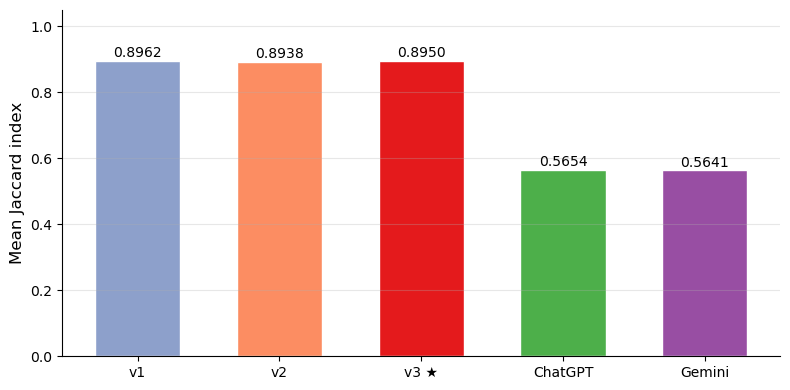

In [6]:
# ── Exp A: summary table ───────────────────────────────────────────────────
rows = []
for k, mname in enumerate(METHODS):
    J_mean_per_cfg = J_A[k].mean(axis=1)        # mean over images, per config
    fps = 1.0 / T_A[k].mean() if T_A[k].mean() > 0 else np.nan
    rows.append({'Method': mname,
                 **{cfg_names[j]: f'{J_mean_per_cfg[j]:.4f}' for j in range(n_cfg)},
                 'Mean': f'{J_mean_per_cfg.mean():.4f}',
                 'FPS': f'{fps:.1f}'})
df_A = pd.DataFrame(rows).set_index('Method')
display(df_A)

# ── Exp A: bar chart — mean Jaccard across selected configs ───────────────
fig, ax = plt.subplots(figsize=(8, 4))
means = [J_A[k].mean() for k in range(n_meth)]
bars = ax.bar(METHODS, means, color=[COLORS[m] for m in METHODS],
              width=0.6, edgecolor='white')
for bar, v in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Mean Jaccard index', fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Experiment B1 — Synthetic semicircle (outliers 0–5)

In [7]:
# B1 setup (matches CLAUDE.md / main_3C_FBI.py)
x0, y0, r0  = B1_X0, B1_Y0, B1_R0
xmax_B1     = x0 + r0        # 150
ymax_B1     = y0             # 60
rmax_B1     = r0 * 2         # 200
rmin_B1     = 4
outlier_range = list(range(6))

# B1: x can be negative (x_min ≈ -50). Shift x by +100 for image-based methods.
B1_X_SHIFT = r0   # 100

J_B1  = np.zeros((n_meth, len(outlier_range)))
AD_B1 = np.zeros_like(J_B1)
R_B1  = np.zeros_like(J_B1)
T_B1  = np.zeros_like(J_B1)

print(f'Exp B1: {len(outlier_range)} outlier configs × {n_meth} methods × {N_MC_B1} iters')
t0 = time.time()

for oi, n_out in enumerate(outlier_range):
    J_buf  = np.zeros((n_meth, N_MC_B1))
    AD_buf = np.zeros_like(J_buf)
    R_buf  = np.zeros_like(J_buf)
    T_buf  = np.zeros_like(J_buf)

    for it in range(N_MC_B1):
        rng = np.random.default_rng(it * 1000 + oi)
        pts = generate_semicircle(x0, y0, r0, n=50, noise=1.0, n_out=n_out, rng=rng)

        for k, mname in enumerate(METHODS):
            try:
                t1 = time.time()
                if mname in ('ChatGPT', 'Gemini'):
                    res = WRAPPERS_B[mname](pts, xmax_B1, ymax_B1, rmax_B1, rmin_B1,
                                           x_shift=B1_X_SHIFT)
                else:
                    res = WRAPPERS_B[mname](pts, xmax_B1, ymax_B1, rmax_B1, rmin_B1)
                T_buf[k, it] = time.time() - t1
                if res is not None:
                    cx, cy, rc = res
                    J_buf[k, it]  = jaccard_circles(x0, y0, r0, cx, cy, rc)
                    AD_buf[k, it] = np.hypot(cx-x0, cy-y0)
                    R_buf[k, it]  = abs(rc - r0)
            except Exception:
                pass

    J_B1[:,oi]  = J_buf.mean(axis=1)
    AD_B1[:,oi] = AD_buf.mean(axis=1)
    R_B1[:,oi]  = R_buf.mean(axis=1)
    T_B1[:,oi]  = T_buf.mean(axis=1)
    print(f'  outliers={n_out}  ({time.time()-t0:.1f}s)')

print(f'Done in {time.time()-t0:.1f}s')

Exp B1: 6 outlier configs × 5 methods × 100 iters
  outliers=0  (32.8s)
  outliers=1  (67.8s)
  outliers=2  (100.8s)
  outliers=3  (133.3s)
  outliers=4  (165.2s)
  outliers=5  (199.8s)
Done in 199.8s


,Mean J,Mean AD (mm),Mean R err (mm),FPS
Method,,,,
v1,0.9889,0.709,0.409,138.1
v2,0.9869,0.850,0.528,3.6
v3 ★,0.9917,0.519,0.314,231.7
ChatGPT,0.8563,12.221,5.922,37.7
Gemini,0.8596,12.116,5.152,54.6


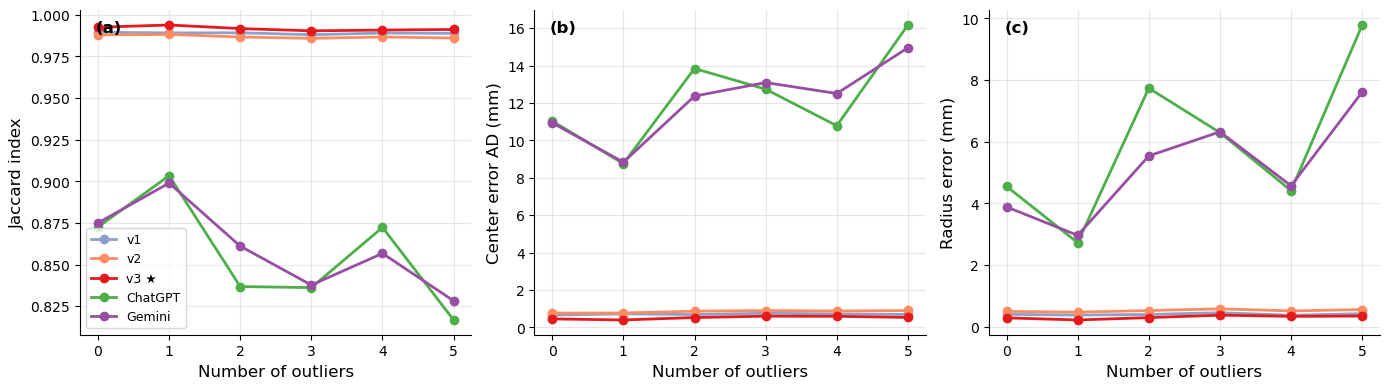

In [8]:
# ── B1: summary table (mean over outlier levels) ───────────────────────────
rows = []
for k, mname in enumerate(METHODS):
    rows.append({'Method': mname,
                 'Mean J': f'{J_B1[k].mean():.4f}',
                 'Mean AD (mm)': f'{AD_B1[k].mean():.3f}',
                 'Mean R err (mm)': f'{R_B1[k].mean():.3f}',
                 'FPS': f'{1/T_B1[k].mean():.1f}'})
display(pd.DataFrame(rows).set_index('Method'))

# ── B1: Jaccard vs outlier count ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ['(a) Jaccard index', '(b) Center error AD (mm)', '(c) Radius error (mm)']
data   = [J_B1, AD_B1, R_B1]

for ax, dat, lbl in zip(axes, data, labels):
    for k, mname in enumerate(METHODS):
        ax.plot(outlier_range, dat[k], marker='o', label=mname,
                color=COLORS[mname], linewidth=2, markersize=6)
    ax.set_xlabel('Number of outliers', fontsize=12)
    ax.set_ylabel(lbl.split('] ')[0].replace('(a) ','').replace('(b) ','').replace('(c) ',''),
                  fontsize=12)
    ax.text(0.04, 0.97, lbl[:3], transform=ax.transAxes,
            va='top', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

## Experiment B2 — Synthetic full circle (9 q × 5 noise × 8 outlier)

In [ ]:
from joblib import Parallel, delayed

def run_one_cell(ni, oi, qi):
    """One (noise, outlier, q) cell — called in parallel by Exp B2."""
    np_pct    = NOISE_PCT[ni]
    op        = OUTLIER_PCT[oi]
    q         = Q_VALUES[qi]
    noise_std = (np_pct / 100.0) * B2_R0
    n_out     = round(op / 100.0 * B2_N)

    if q > 0:
        x0_q = int(B2_X0 // q); y0_q = int(B2_Y0 // q); r0_q = int(B2_R0 // q)
        xmax = max(x0_q + r0_q, 10); ymax = max(y0_q + r0_q, 10)
        rmax = max(int(r0_q * 2), 5); rmin = min(4, max(1, r0_q - 1))
    else:
        x0_q, y0_q, r0_q = B2_X0, B2_Y0, B2_R0
        xmax = B2_X0 + B2_R0; ymax = B2_Y0 + B2_R0
        rmax = int(B2_R0 * 2); rmin = 4

    J_buf = np.zeros((n_meth, N_MC_B2))
    T_buf = np.zeros_like(J_buf)

    for it in range(N_MC_B2):
        seed = it * 10000 + ni * 1000 + oi * 100 + qi
        rng  = np.random.default_rng(seed)
        pts  = generate_circle(B2_X0, B2_Y0, B2_R0, n=B2_N,
                               noise=noise_std, n_out=n_out, rng=rng)
        pts_q = apply_quantization(pts, q)
        if len(pts_q) < 3:
            continue

        for k, mname in enumerate(METHODS):
            try:
                t1 = time.time()
                res = WRAPPERS_B[mname](pts_q, xmax, ymax, rmax, rmin)
                T_buf[k, it] = time.time() - t1
                if res is not None:
                    cx, cy, rc = res
                    J_buf[k, it] = jaccard_circles(x0_q, y0_q, r0_q, cx, cy, rc)
            except Exception:
                pass

    return ni, oi, qi, J_buf.mean(axis=1), T_buf.mean(axis=1)

print('run_one_cell defined')

In [ ]:
nN, nO, nQ = len(NOISE_PCT), len(OUTLIER_PCT), len(Q_VALUES)
J_B2  = np.zeros((n_meth, nN, nO, nQ))
T_B2  = np.zeros_like(J_B2)
total = nN * nO * nQ

print(f'Exp B2: {total} configs × {n_meth} methods × {N_MC_B2} iters  (parallel)')
t0 = time.time()

cell_results = Parallel(n_jobs=-1, prefer='threads', verbose=5)(
    delayed(run_one_cell)(ni, oi, qi)
    for ni in range(nN)
    for oi in range(nO)
    for qi in range(nQ)
)

for ni, oi, qi, j_mean, t_mean in cell_results:
    J_B2[:, ni, oi, qi] = j_mean
    T_B2[:, ni, oi, qi] = t_mean

print(f'Done in {time.time()-t0:.1f}s')

Win counts (360 cells):
  v1            121  (33.6%)
  ChatGPT        90  (25.0%)
  Gemini         87  (24.2%)
  v3 ★           52  (14.4%)
  v2             10  (2.8%)


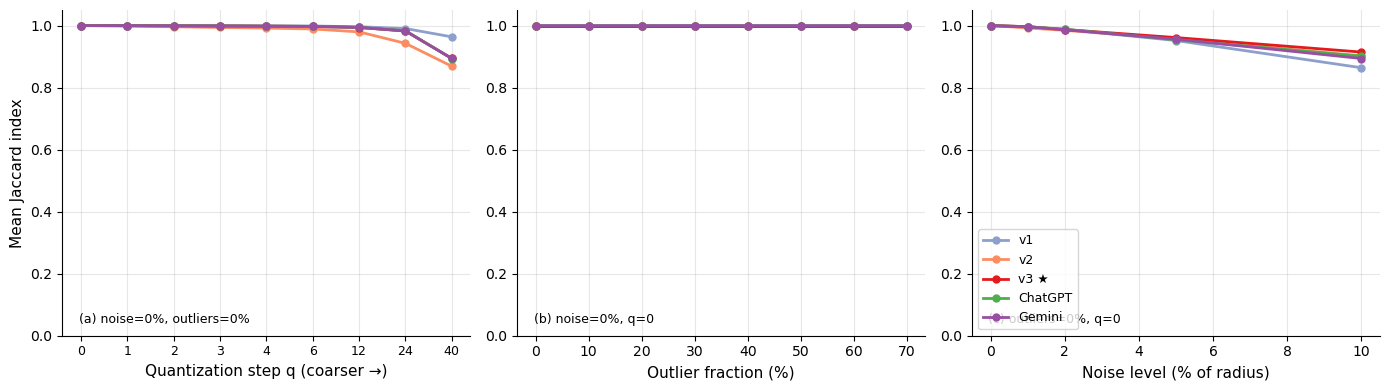

In [10]:
# ── B2: win count (best Jaccard per cell) ─────────────────────────────────
best_idx = np.argmax(J_B2, axis=0)   # (nN, nO, nQ)
wins = {mname: int(np.sum(best_idx == k)) for k, mname in enumerate(METHODS)}
print('Win counts (360 cells):')
for m, w in sorted(wins.items(), key=lambda x: -x[1]):
    print(f'  {m:<12} {w:>4}  ({100*w/total:.1f}%)')

# ── B2: line plots — vs quantization, vs outliers, vs noise ───────────────
ni0 = NOISE_PCT.index(0)
oi0 = OUTLIER_PCT.index(0)
qi0 = Q_VALUES.index(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) vs quantization
ax = axes[0]
for k, mname in enumerate(METHODS):
    ax.plot(range(nQ), J_B2[k, ni0, oi0, :], marker='o',
            color=COLORS[mname], label=mname, linewidth=2, markersize=5)
ax.set_xticks(range(nQ)); ax.set_xticklabels([str(q) for q in Q_VALUES], fontsize=9)
ax.set_xlabel('Quantization step q (coarser →)', fontsize=11)
ax.set_ylabel('Mean Jaccard index', fontsize=11)
ax.text(0.04, 0.04, '(a) noise=0%, outliers=0%', transform=ax.transAxes, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)

# (b) vs outlier fraction
ax = axes[1]
for k, mname in enumerate(METHODS):
    ax.plot(OUTLIER_PCT, J_B2[k, ni0, :, qi0], marker='o',
            color=COLORS[mname], label=mname, linewidth=2, markersize=5)
ax.set_xlabel('Outlier fraction (%)', fontsize=11)
ax.text(0.04, 0.04, '(b) noise=0%, q=0', transform=ax.transAxes, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)

# (c) vs noise
ax = axes[2]
for k, mname in enumerate(METHODS):
    ax.plot(NOISE_PCT, J_B2[k, :, oi0, qi0], marker='o',
            color=COLORS[mname], label=mname, linewidth=2, markersize=5)
ax.set_xlabel('Noise level (% of radius)', fontsize=11)
ax.text(0.04, 0.04, '(c) outliers=0%, q=0', transform=ax.transAxes, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

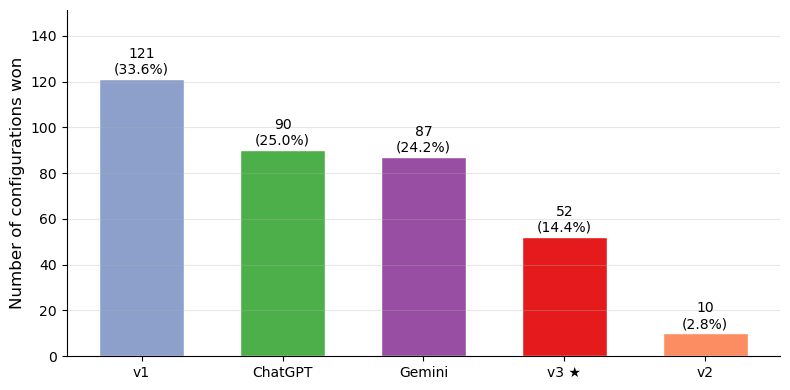

In [11]:
# ── B2: win-count bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sorted_methods = sorted(wins, key=lambda m: -wins[m])
w_vals = [wins[m] for m in sorted_methods]
bars = ax.bar(sorted_methods, w_vals,
              color=[COLORS[m] for m in sorted_methods],
              width=0.6, edgecolor='white')
for bar, w in zip(bars, w_vals):
    pct = 100*w/total
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{w}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of configurations won', fontsize=12)
ax.set_ylim(0, max(w_vals)*1.25)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Save results to disk

In [ ]:
save_path = os.path.join(PROJECT, 'notebooks', 'compare_5methods_results.npz')

np.savez_compressed(
    save_path,
    # Exp A
    J_A          = J_A,
    T_A          = T_A,
    cfg_names    = cfg_names,
    # Exp B1
    J_B1         = J_B1,
    AD_B1        = AD_B1,
    R_B1         = R_B1,
    T_B1         = T_B1,
    outlier_range= outlier_range,
    # Exp B2
    J_B2         = J_B2,
    T_B2         = T_B2,
    NOISE_PCT    = NOISE_PCT,
    OUTLIER_PCT  = OUTLIER_PCT,
    Q_VALUES     = Q_VALUES,
    METHODS      = METHODS,
)
print(f'Saved → {save_path}')

---
## Plots only — load saved results (skip all run cells above)

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# ── Find PROJECT root (same logic as cell-setup) ───────────────────────────
_here = os.getcwd()
PROJECT = os.path.dirname(_here) if os.path.basename(_here) == 'notebooks' else _here

# ── Load ───────────────────────────────────────────────────────────────────
data = np.load(os.path.join(PROJECT, 'notebooks', 'compare_5methods_results.npz'),
               allow_pickle=True)

J_A           = data['J_A']
T_A           = data['T_A']
cfg_names     = data['cfg_names'].tolist()
J_B1          = data['J_B1']
AD_B1         = data['AD_B1']
R_B1          = data['R_B1']
T_B1          = data['T_B1']
outlier_range = data['outlier_range'].tolist()
J_B2          = data['J_B2']
T_B2          = data['T_B2']
NOISE_PCT     = data['NOISE_PCT'].tolist()
OUTLIER_PCT   = data['OUTLIER_PCT'].tolist()
Q_VALUES      = data['Q_VALUES'].tolist()
METHODS       = data['METHODS'].tolist()

n_meth = J_A.shape[0]
n_cfg  = J_A.shape[1]
nN, nO, nQ = J_B2.shape[1], J_B2.shape[2], J_B2.shape[3]
total  = nN * nO * nQ

COLORS = {'v1':'#8da0cb', 'v2':'#fc8d62', 'v3 ★':'#e41a1c',
          'ChatGPT':'#4daf4a', 'Gemini':'#984ea3'}

print('Data loaded — ready to plot')

Data loaded — ready to plot


,GL80,GL82,GL84,Mean,FPS
Method,,,,,
v1,0.8948,0.8970,0.8962,0.8960,99.0
v2,0.8948,0.8950,0.8970,0.8956,36.0
v3 ★,0.8948,0.8965,0.8950,0.8954,133.7
ChatGPT,0.5706,0.5612,0.5567,0.5628,35.9
Gemini,0.5621,0.5639,0.5609,0.5623,52.4


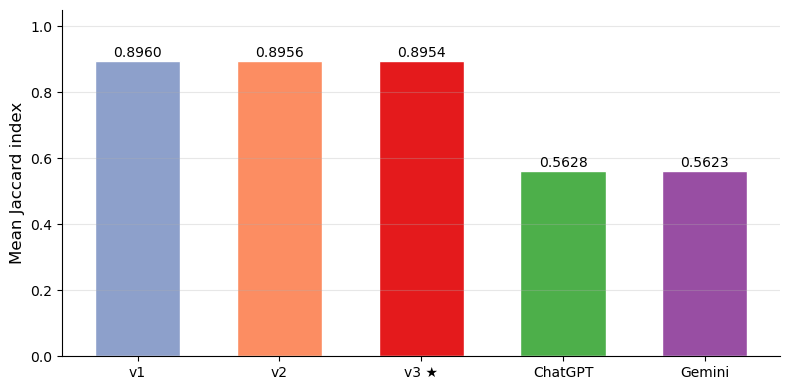

In [2]:
# ── Exp A: summary table ───────────────────────────────────────────────────
rows = []
for k, mname in enumerate(METHODS):
    J_mean_per_cfg = J_A[k].mean(axis=1)
    fps = 1.0 / T_A[k].mean() if T_A[k].mean() > 0 else np.nan
    rows.append({'Method': mname,
                 **{cfg_names[j]: f'{J_mean_per_cfg[j]:.4f}' for j in range(n_cfg)},
                 'Mean': f'{J_mean_per_cfg.mean():.4f}',
                 'FPS': f'{fps:.1f}'})
display(pd.DataFrame(rows).set_index('Method'))

# ── Exp A: bar chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
means = [J_A[k].mean() for k in range(n_meth)]
bars  = ax.bar(METHODS, means, color=[COLORS[m] for m in METHODS],
               width=0.6, edgecolor='white')
for bar, v in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Mean Jaccard index', fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

,Mean J,Mean AD (mm),Mean R err (mm),FPS
Method,,,,
v1,0.9890,0.709,0.397,141.7
v2,0.9872,0.825,0.513,3.7
v3 ★,0.9916,0.524,0.322,234.8
ChatGPT,0.8609,11.925,5.571,38.0
Gemini,0.8240,15.592,8.088,1654.1


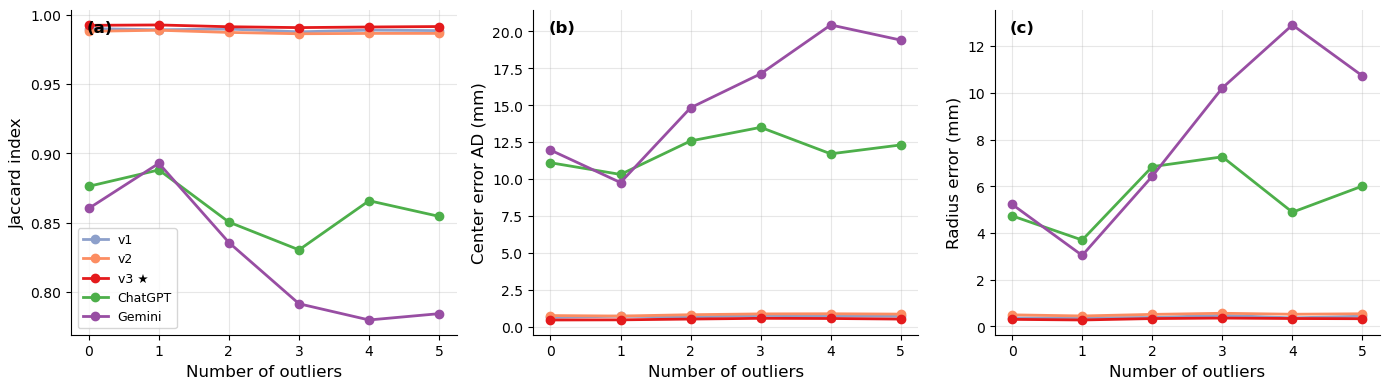

In [3]:
# ── B1: summary table ──────────────────────────────────────────────────────
rows = []
for k, mname in enumerate(METHODS):
    rows.append({'Method': mname,
                 'Mean J':           f'{J_B1[k].mean():.4f}',
                 'Mean AD (mm)':     f'{AD_B1[k].mean():.3f}',
                 'Mean R err (mm)':  f'{R_B1[k].mean():.3f}',
                 'FPS':              f'{1/T_B1[k].mean():.1f}'})
display(pd.DataFrame(rows).set_index('Method'))

# ── B1: Jaccard, center error, radius error vs outlier count ───────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
panel_labels = ['(a) Jaccard index', '(b) Center error AD (mm)', '(c) Radius error (mm)']
ylabels      = ['Jaccard index', 'Center error AD (mm)', 'Radius error (mm)']
data_arrays  = [J_B1, AD_B1, R_B1]

for ax, dat, lbl, ylab in zip(axes, data_arrays, panel_labels, ylabels):
    for k, mname in enumerate(METHODS):
        ax.plot(outlier_range, dat[k], marker='o', label=mname,
                color=COLORS[mname], linewidth=2, markersize=6)
    ax.set_xlabel('Number of outliers', fontsize=12)
    ax.set_ylabel(ylab, fontsize=12)
    ax.text(0.04, 0.97, lbl[:3], transform=ax.transAxes,
            va='top', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

Win counts (360 cells):
  v1            122  (33.9%)
  ChatGPT        91  (25.3%)
  Gemini         75  (20.8%)
  v3 ★           62  (17.2%)
  v2             10  (2.8%)


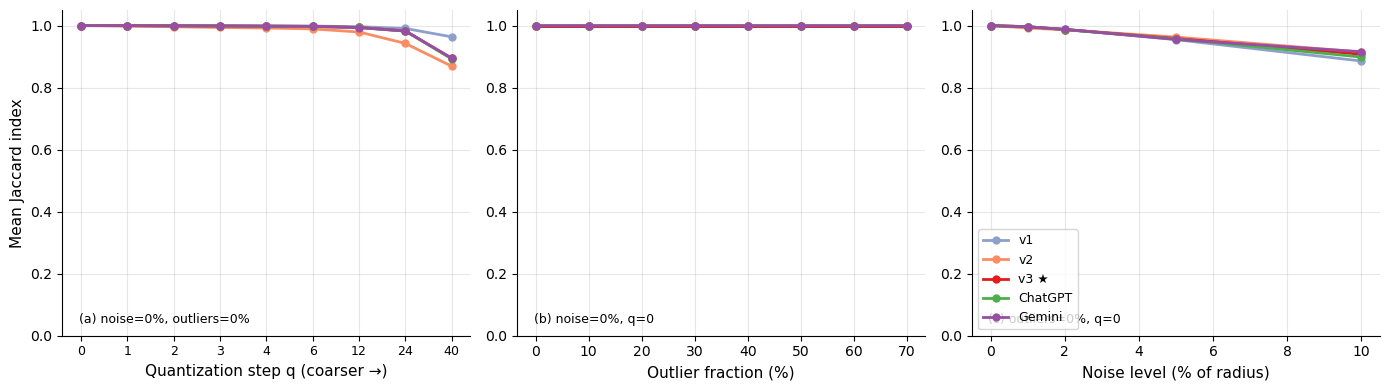

In [4]:
# ── B2: win count ──────────────────────────────────────────────────────────
best_idx = np.argmax(J_B2, axis=0)
wins = {mname: int(np.sum(best_idx == k)) for k, mname in enumerate(METHODS)}
print('Win counts (360 cells):')
for m, w in sorted(wins.items(), key=lambda x: -x[1]):
    print(f'  {m:<12} {w:>4}  ({100*w/total:.1f}%)')

# ── B2: line plots — vs quantization, vs outliers, vs noise ───────────────
ni0 = NOISE_PCT.index(0)
oi0 = OUTLIER_PCT.index(0)
qi0 = Q_VALUES.index(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
for k, mname in enumerate(METHODS):
    ax.plot(range(nQ), J_B2[k, ni0, oi0, :], marker='o',
            color=COLORS[mname], label=mname, linewidth=2, markersize=5)
ax.set_xticks(range(nQ)); ax.set_xticklabels([str(q) for q in Q_VALUES], fontsize=9)
ax.set_xlabel('Quantization step q (coarser →)', fontsize=11)
ax.set_ylabel('Mean Jaccard index', fontsize=11)
ax.text(0.04, 0.04, '(a) noise=0%, outliers=0%', transform=ax.transAxes, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)

ax = axes[1]
for k, mname in enumerate(METHODS):
    ax.plot(OUTLIER_PCT, J_B2[k, ni0, :, qi0], marker='o',
            color=COLORS[mname], label=mname, linewidth=2, markersize=5)
ax.set_xlabel('Outlier fraction (%)', fontsize=11)
ax.text(0.04, 0.04, '(b) noise=0%, q=0', transform=ax.transAxes, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)

ax = axes[2]
for k, mname in enumerate(METHODS):
    ax.plot(NOISE_PCT, J_B2[k, :, oi0, qi0], marker='o',
            color=COLORS[mname], label=mname, linewidth=2, markersize=5)
ax.set_xlabel('Noise level (% of radius)', fontsize=11)
ax.text(0.04, 0.04, '(c) outliers=0%, q=0', transform=ax.transAxes, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

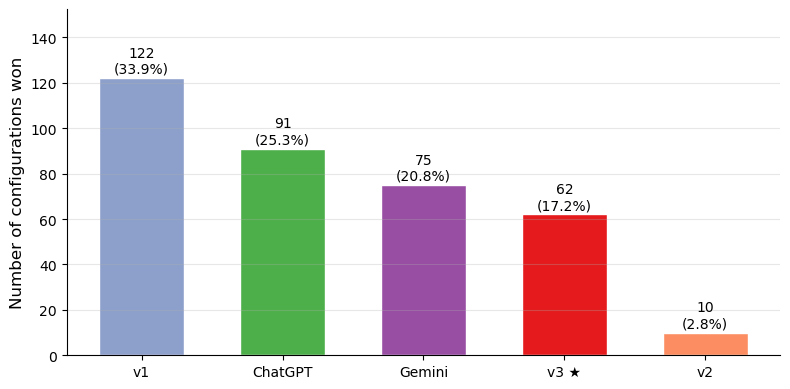

In [5]:
# ── B2: win-count bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sorted_methods = sorted(wins, key=lambda m: -wins[m])
w_vals = [wins[m] for m in sorted_methods]
bars = ax.bar(sorted_methods, w_vals,
              color=[COLORS[m] for m in sorted_methods],
              width=0.6, edgecolor='white')
for bar, w in zip(bars, w_vals):
    pct = 100*w/total
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{w}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of configurations won', fontsize=12)
ax.set_ylim(0, max(w_vals)*1.25)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()